### life expectancy project
    
#### the goal of this project will be to study life expenctancy of the countries on the data set. 
 Y = Life_expectancy at birth
 the analysis will have a top down approach, trying to establish a correlation between GDP and Y
 y= beta(gdp)+err
#### then, the I will go into each country on the dataset
 each country will have an analysis of life expectancy across time and gdp across time 
 and each country will have its own regression
#### then I will compare the countries against each other to understand if gpd variations in different countries impact life expectancy differently. 



In [1]:
# resources
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()


In [2]:
#loading data 
df = pd.read_csv('all_data.csv')
df.head()


,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [3]:
# checking variables
countries = df.Country.unique()
countries

array(['Chile', 'China', 'Germany', 'Mexico', 'United States of America',
       'Zimbabwe'], dtype=object)

In [4]:
df.describe()

,Year,Life expectancy at birth (years),GDP
count,96.000000,96.000000,9.600000e+01
mean,2007.500000,72.789583,3.880499e+12
std,4.633971,10.672882,5.197561e+12
min,2000.000000,44.300000,4.415703e+09
25%,2003.750000,74.475000,1.733018e+11
50%,2007.500000,76.750000,1.280220e+12
75%,2011.250000,78.900000,4.067510e+12
max,2015.000000,81.000000,1.810000e+13


In [5]:
#renaming life expectancy collumn to easier manipulation
df.rename(columns={'Life expectancy at birth (years)': 'life_expectancy_ab', 'GDP':'gdp'}, inplace=True)
df.head()


,Country,Year,life_expectancy_ab,gdp
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [6]:
mod = sm.OLS(endog=df.life_expectancy_ab, exog=df.gdp)
res = mod.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     life_expectancy_ab   R-squared (uncentered):                   0.401
Model:                            OLS   Adj. R-squared (uncentered):              0.395
Method:                 Least Squares   F-statistic:                              63.72
Date:                Tue, 16 Dec 2025   Prob (F-statistic):                    3.28e-12
Time:                        14:16:17   Log-Likelihood:                         -524.20
No. Observations:                  96   AIC:                                      1050.
Df Residuals:                      95   BIC:                                      1053.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
gdp          7.21e-12   9.03e-13      7.982      0.000    5.42e-12       9e-12
==============================================================================
Omnibus:                       21.390   Durbin-Watson:                   0.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.740
Skew:                          -1.296   Prob(JB):                     9.47e-07
Kurtosis:                       3.460   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

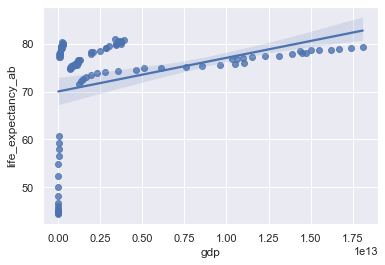

<Figure size 432x288 with 0 Axes>

In [7]:
sns.regplot(data=df,
            x='gdp',
            y='life_expectancy_ab')
plt.show()
plt.clf()



this wont tell us much since it is clear that there is heterocedasticity of the errors

In [8]:
df_chile = df[df['Country'] == 'Chile']
df_china = df[df['Country'] == 'China']
df_ger = df[df['Country'] == 'Germany']
df_mex = df[df['Country'] == 'Mexico']
df_us = df[df['Country'] == 'United States of America']
df_zim = df[df['Country'] == 'Zimbabwe']

In [ ]:
list_of_dfs = [df_chile,df_china, df_ger,df_mex,df_us,df_zim]
count=0
for dfs in list_of_dfs:
    dfs['gdp_b'] = df['gdp']/1000000000
    
    plt.figure(figsize=(30,15))
    
    # plt.subplot(2,2,(1,2))
    sns.regplot(data=dfs,
                x='gdp_b',
                y='life_expectancy_ab')
    plt.title(countries[count])
    
    # plt.subplot(2,2,3)
    sns.relplot(data=dfs,
                x='Year',
                y= 'gdp_b')
    
    # plt.subplot(2,2,4)
    sns.relplot(data=dfs,
                x='Year',
                y= 'life_expectancy_ab')

    plt.show()
    plt.clf()
    mod = sm.OLS(endog=dfs.life_expectancy_ab, exog=dfs.gdp_b)
    res = mod.fit()
    count+=1
    print(res.summary())

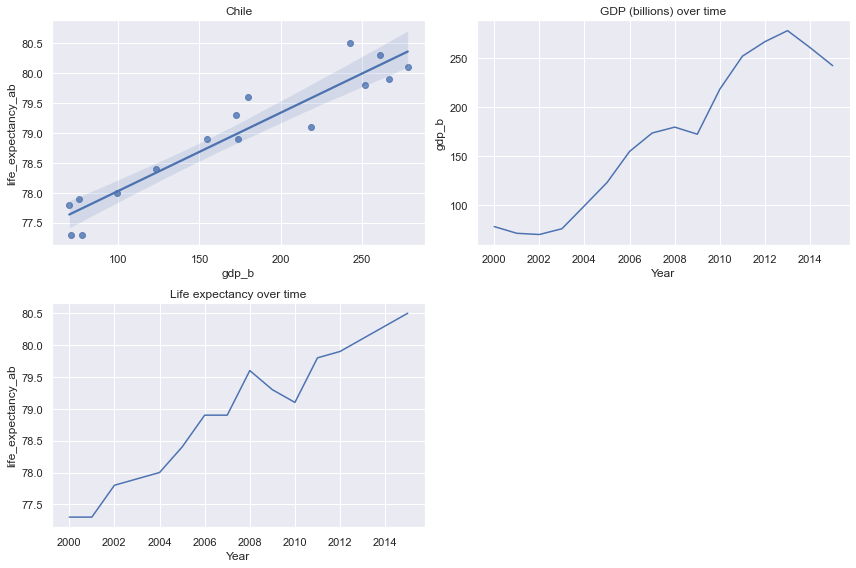

--- Chile OLS results ---
                            OLS Regression Results                            
Dep. Variable:     life_expectancy_ab   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     129.2
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.87e-08
Time:                        17:00:02   Log-Likelihood:                -4.4985
No. Observations:                  16   AIC:                             13.00
Df Residuals:                      14   BIC:                             14.54
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.7223     

c:\Users\Rudah\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


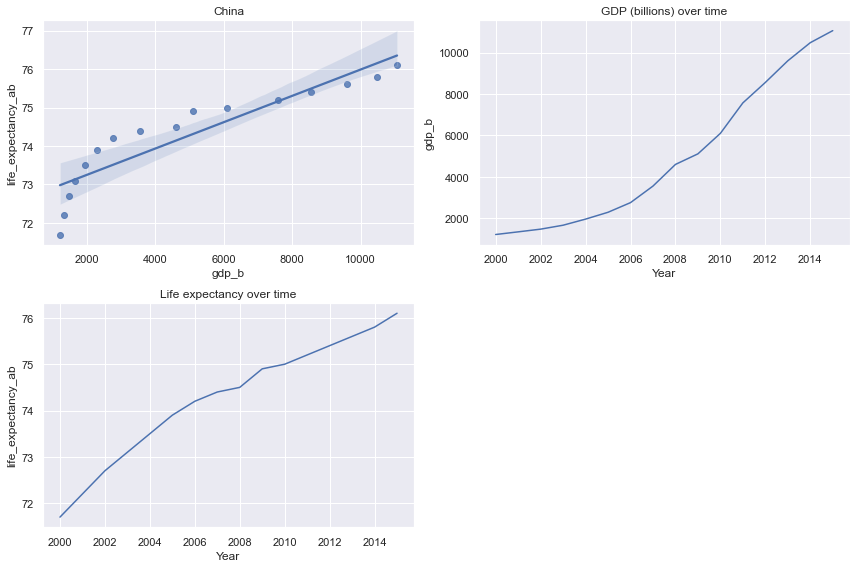

--- China OLS results ---
                            OLS Regression Results                            
Dep. Variable:     life_expectancy_ab   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     66.19
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.13e-06
Time:                        17:00:03   Log-Likelihood:                -12.642
No. Observations:                  16   AIC:                             29.28
Df Residuals:                      14   BIC:                             30.83
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         72.5669     

c:\Users\Rudah\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


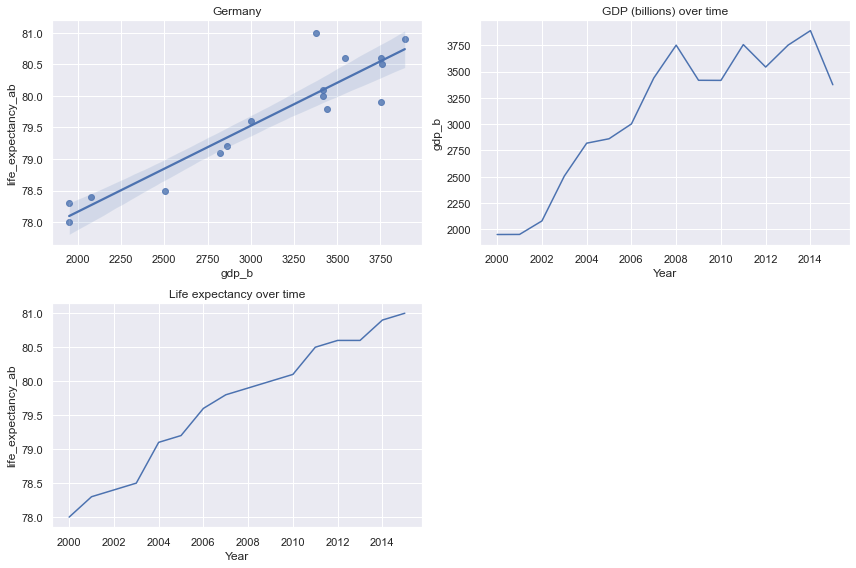

--- Germany OLS results ---
                            OLS Regression Results                            
Dep. Variable:     life_expectancy_ab   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     93.63
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.40e-07
Time:                        17:00:04   Log-Likelihood:                -5.4643
No. Observations:                  16   AIC:                             14.93
Df Residuals:                      14   BIC:                             16.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.4399   

c:\Users\Rudah\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


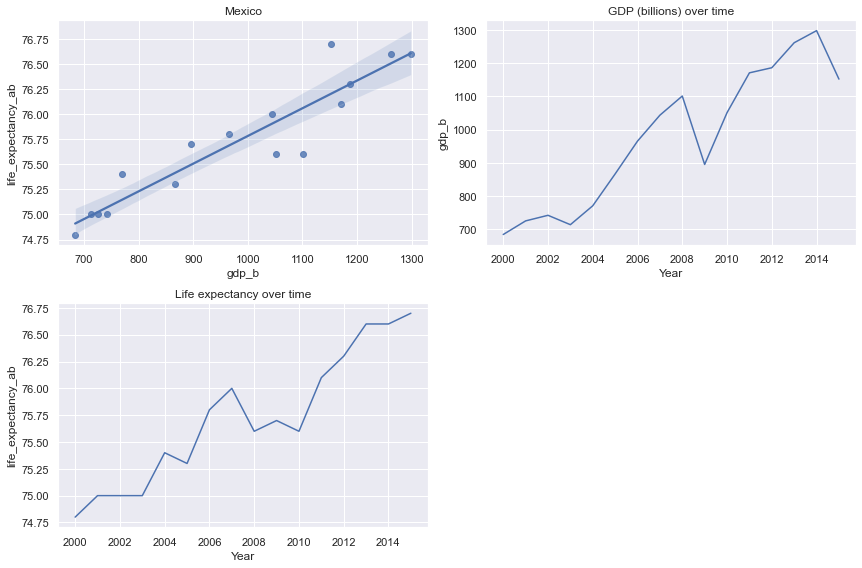

--- Mexico OLS results ---
                            OLS Regression Results                            
Dep. Variable:     life_expectancy_ab   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     92.93
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.47e-07
Time:                        17:00:05   Log-Likelihood:                 1.7010
No. Observations:                  16   AIC:                            0.5980
Df Residuals:                      14   BIC:                             2.143
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         73.0209    

c:\Users\Rudah\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


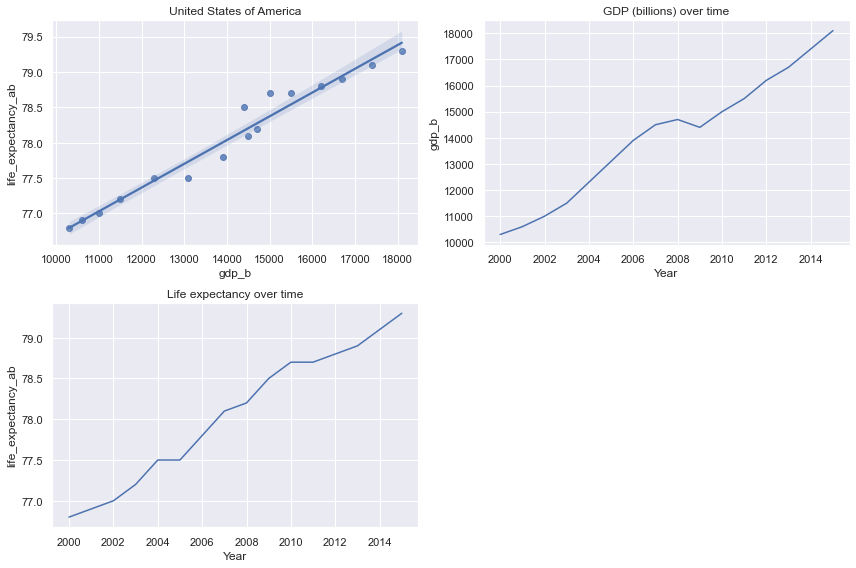

--- United States of America OLS results ---
                            OLS Regression Results                            
Dep. Variable:     life_expectancy_ab   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     372.2
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.75e-11
Time:                        17:00:06   Log-Likelihood:                 7.2844
No. Observations:                  16   AIC:                            -10.57
Df Residuals:                      14   BIC:                            -9.024
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

c:\Users\Rudah\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


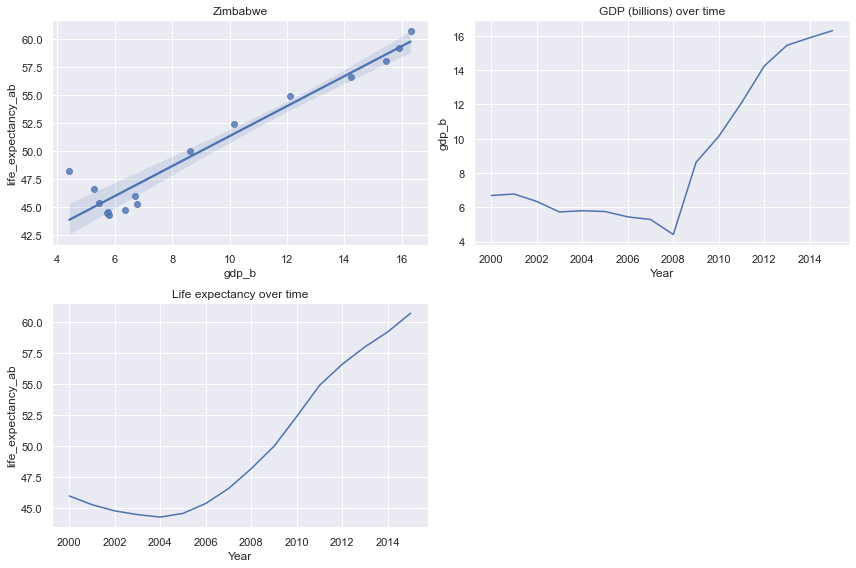

--- Zimbabwe OLS results ---
                            OLS Regression Results                            
Dep. Variable:     life_expectancy_ab   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     196.7
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.24e-09
Time:                        17:00:07   Log-Likelihood:                -29.005
No. Observations:                  16   AIC:                             62.01
Df Residuals:                      14   BIC:                             63.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.9925  

c:\Users\Rudah\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [39]:
list_of_dfs = [df_chile, df_china, df_ger, df_mex, df_us, df_zim]
for idx, dfs in enumerate(list_of_dfs):
    # work on a copy to avoid SettingWithCopyWarning
    dfs = dfs.copy()
    dfs['gdp_b'] = dfs['gdp'] / 1e9

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Regression plot (GDP vs Life expectancy)
    sns.regplot(data=dfs, x='gdp_b', y='life_expectancy_ab', ax=axs[0, 0])
    axs[0, 0].set_title(countries[idx])

    # GDP over time
    sns.lineplot(data=dfs, x='Year', y='gdp_b', ax=axs[0, 1])
    axs[0, 1].set_title('GDP (billions) over time')

    # Life expectancy over time
    sns.lineplot(data=dfs, x='Year', y='life_expectancy_ab', ax=axs[1, 0])
    axs[1, 0].set_title('Life expectancy over time')

    # hide unused axis
    axs[1, 1].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # Regression with constant
    X = sm.add_constant(dfs['gdp_b'])
    y = dfs['life_expectancy_ab']
    mod = sm.OLS(endog=y, exog=X)
    res = mod.fit()
    print(f"--- {countries[idx]} OLS results ---")
    print(res.summary())

### conclusion:
1. with our limited dataset, and a CI of 95%, GDP is a siginificant variable to explain the variation of life expectancy and has a positive correlation in all observations
2. among our observations, Zimbabwe has the highest coeficient, while US and China have the lowest. Meaning that a variation of GDP will have a greater impact on life expectancy in Zimbabwe, and the lower impact on the US and China . 
     - this might imply a diminishing return effect or a cap on life expectancy in itself 
3. Rsquared in all our observations were above 95% percent, meaning that the model predicts most of the variations observed. And the F-test also attest that the models have a good fit as we would reject the null hypothesis in all scenarios.

### issues:
1. despite the conclusions above, the limited sample size of the dataset might not completly reflect the reality of the phenomena
2. it is also possible that there are confounding variables that affect both variables, and the collinearity among the variables may also invalidate the analysis.

### next steps:
1. Increasing the number of observations for each country. It might reduce the quality of the model (Rsquared reduction) but if the same relations is manttained it will give strenght to our conclusions.
2. Test addtional variables. It will be more time consuming, but will help clear out possible confounding variables and multicollinearity